<h1 style="color: #2ecc71; ">GitHub Repository Exploratory Data Analysis</h1>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns



<h2 style="color: #f4ed60; font-family: 'Courier New', monospace;"</h2>Dataset Loading<h2>

In [299]:
df = pd.read_csv(r"..\data\processed\github_repositories_cleaned.csv")

<h2 style="color: #f4ed60; font-family: 'Courier New', monospace;"</h2>Dataset Overview<h2>


This section provides a high-level view of the GitHub repository dataset, including dataset size, repository metrics, and the time span covered by the collected repositories.

In [300]:
df.head()

,owner,name,description,stars,forks,repo_size,language,created_at,updated_at,created_year,...,topics,has_issues,has_wiki,has_discussions,archived,default_branch,visibility,url,license_cleaned,license_category
0,PaddlePaddle,PaddlePaddle/PaddleOCR,Turn any PDF or image document into structured...,90517,11434,1970859,Python,2020-05-08 10:38:16+00:00,2026-10-02 12:46:09+00:00,2020,...,"['ai4science', 'chineseocr', 'document-parsing...",True,False,True,False,main,public,https://github.com/PaddlePaddle/PaddleOCR,Apache-2.0,Permissive (Safe)
1,Z4nzu,Z4nzu/hackingtool,ALL IN ONE Hacking Tool For Hackers,80037,9082,6457,Python,2020-04-11 09:21:31+00:00,2026-10-02 12:41:44+00:00,2020,...,"['allinonehackingtool', 'besthackingtool', 'ct...",True,True,False,False,master,public,https://github.com/Z4nzu/hackingtool,MIT,Permissive (Safe)
2,ultralytics,ultralytics/yolov5,Ultralytics YOLOv5 in PyTorch for object detec...,58105,17459,18147,Python,2020-05-18 03:45:11+00:00,2026-10-02 09:39:53+00:00,2020,...,"['computer-vision', 'coreml', 'deep-learning',...",True,True,True,False,master,public,https://github.com/ultralytics/yolov5,AGPL-3.0,Copyleft (Risky for Commercial)
3,SimplifyJobs,SimplifyJobs/Summer2027-Internships,"Summer 2027 software engineering, data science...",47823,3257,4395571,Python,2020-05-23 20:53:18+00:00,2026-10-02 13:01:51+00:00,2020,...,"['data-science', 'fall-2026', 'github', 'inter...",True,False,False,False,dev,public,https://github.com/SimplifyJobs/Summer2027-Int...,Unspecified,Unknown / Risk
4,coqui-ai,coqui-ai/TTS,🐸💬 - a deep learning toolkit for Text-to-Speec...,46097,6166,170196,Python,2020-05-20 15:45:28+00:00,2026-10-02 12:33:13+00:00,2020,...,"['deep-learning', 'glow-tts', 'hifigan', 'melg...",True,True,True,False,dev,public,https://github.com/coqui-ai/TTS,MPL-2.0,Other


In [301]:
df.shape

(24162, 22)

In [302]:

df[["stars","forks","repo_size","open_issues"]].agg(["mean","median","min","max",'std']).rename({"mean":"Average","max":"maximum",'min':"minimum","std":"standard deviation"})


,stars,forks,repo_size,open_issues
Average,1063.424716,141.894669,5.343883e+04,19.722664
median,27.000000,4.000000,1.929000e+03,1.000000
minimum,0.000000,0.000000,0.000000e+00,0.000000
maximum,250707.000000,54953.000000,1.048802e+08,48305.000000
standard deviation,6514.480013,1027.336939,1.039181e+06,335.467850


In [303]:
earliest_year=df["created_year"].min()
print("Earliest Year:",earliest_year)
latest_year = df["created_year"].max()
print("Latest Year:", latest_year)

Earliest Year: 2020
Latest Year: 2026



<h2 style="color: #f4ed60; font-family: 'Courier New', monospace;"</h2>Repository Growth Analysis<h2>

In [304]:
repo_count=df.groupby("created_year")["url"].count().reset_index()
print("No. of Repositories  By Year:\n",repo_count)

No. of Repositories  By Year:
    created_year   url
0          2020  3310
1          2021  3408
2          2022  3416
3          2023  3445
4          2024  3416
5          2025  3536
6          2026  3631


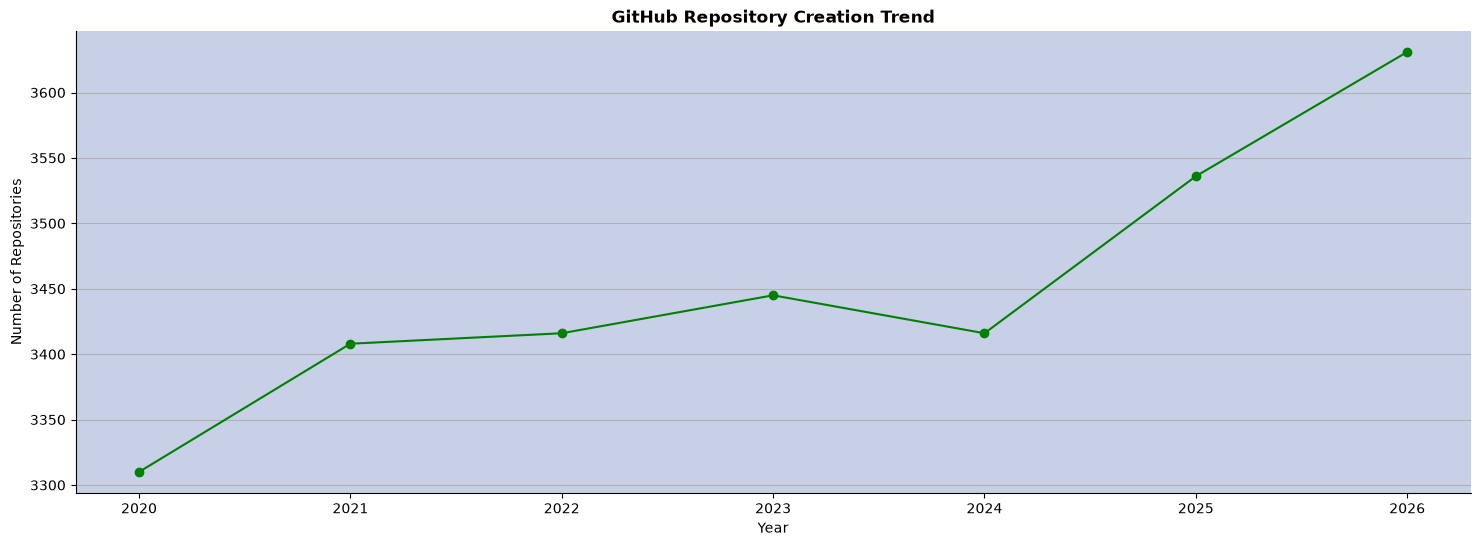

In [305]:
fig = plt.figure(figsize=(18, 6))
ax=plt.axes()
ax.set_facecolor("#c7d0e7")
plt.plot(repo_count["created_year"],repo_count["url"],marker="o",color="green")
plt.title("GitHub Repository Creation Trend",fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Number of Repositories")
plt.grid(axis="y")
ax.spines[["top","right"]].set_visible(False)
plt.show()

What does this show?

This chart shows how the number of repositories in the dataset varies by creation year.


In [306]:
highest_year = repo_count.loc[repo_count["url"].idxmax(), "created_year"]
highest_count = repo_count["url"].max()

print(
    f"Key Insight: Repository creation was highest in {int(highest_year)}, with {int(highest_count):,} repositories."
)


Key Insight: Repository creation was highest in 2026, with 3,631 repositories.



<h2 style="color: #f4ed60; font-family: 'Courier New', monospace;"</h2> Repository Popularity Analysis<h2>


In [307]:
top_repos=df.sort_values(by="stars",ascending=False).head(10)


In [308]:
chart_colors = [
    "#1e293b",
    "#0f172a",
    "#111827",
    "#312e81",
    "#581c87",
    "#701a75",
    "#4c0519",
    "#064e3b",
    "#075985",
    "#7c2d12",
]


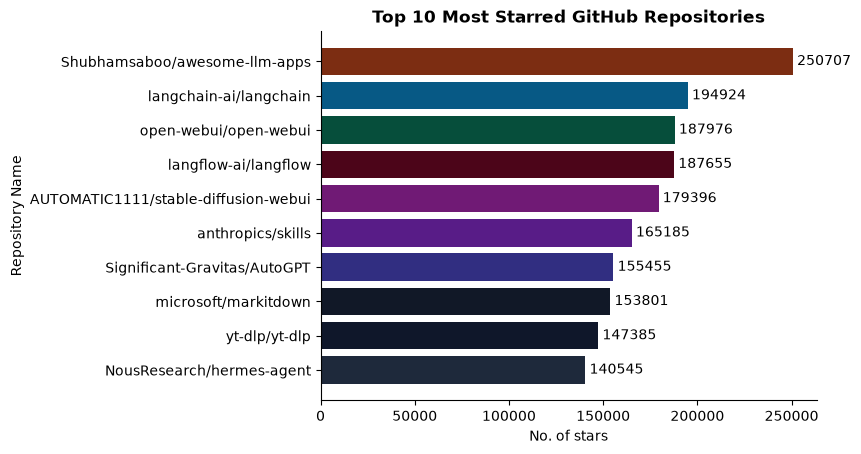

In [309]:
ax=plt.axes()
bars=plt.barh(top_repos["name"], top_repos["stars"][::-1], color=chart_colors)
plt.title("Top 10 Most Starred GitHub Repositories",fontweight="bold")
plt.bar_label(bars,padding=3)
plt.xlabel("No. of stars")
plt.ylabel("Repository Name")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

What does this show?

This chart ranks the top repositories based on GitHub stars, using stars as an indicator of community popularity and visibility.


In [310]:
print(
    f"Key Insight: {top_repos['name'].iloc[0]} is the most-starred repository, with {int(top_repos['stars'].iloc[0]):,} stars."
)


Key Insight: NousResearch/hermes-agent is the most-starred repository, with 250,707 stars.


<h2 style="color: #f4ed60; font-family: 'Courier New', monospace;">Community Engagement Analysis</h2>

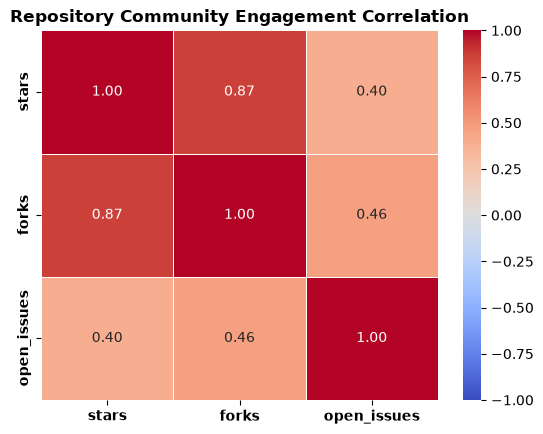

In [311]:
correlation_data=df[["stars","forks","open_issues"]].corr()
sns.heatmap(
    correlation_data,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    vmin=-1,
    vmax=1
)
plt.title("Repository Community Engagement Correlation",fontweight="bold")
plt.xticks(fontsize=10, fontweight="bold")
plt.yticks(fontsize=10, fontweight="bold")
plt.show()

What does this show?

This heatmap shows the relationship between repository stars, forks, and open issues.


In [318]:
correlation_pairs = correlation_data.unstack()

correlation_pairs = correlation_pairs[
    correlation_pairs.index.get_level_values(0)
    != correlation_pairs.index.get_level_values(1)
]

strongest_pair = correlation_pairs.abs().idxmax()

print(
    f"Key Insight: The strongest relationship is between "
    f"{strongest_pair[0]} and {strongest_pair[1]}, "
    f"with a correlation of {correlation_pairs[strongest_pair]:.2f}."
)


Key Insight: The strongest relationship is between stars and forks, with a correlation of 0.87.


<h2 style="color: #f4ed60; font-family: 'Courier New', monospace;">Issue Activity Analysis</h2>

In [ ]:
top_repos_by_issues = df.sort_values(by="open_issues", ascending=False).head(10)[::-1]


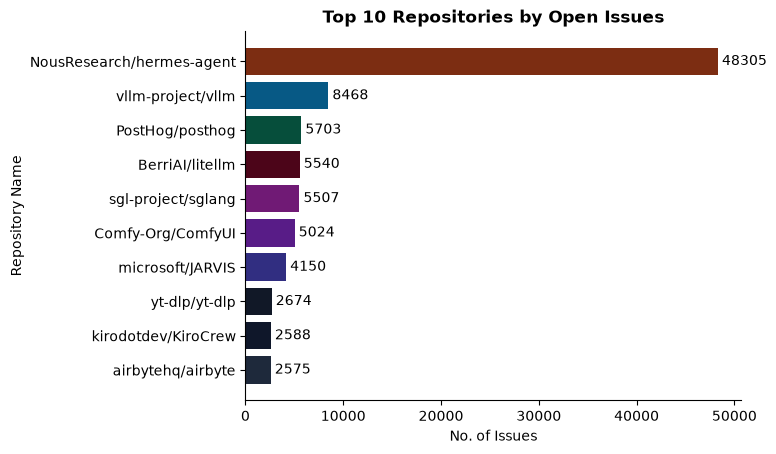

In [ ]:
ax = plt.axes()
bars=plt.barh(top_repos_by_issues["name"],top_repos_by_issues["open_issues"],color=chart_colors)
plt.bar_label(bars,padding=3)
plt.title("Top 10 Repositories by Open Issues",fontweight="bold")
plt.xlabel("No. of Issues")
plt.ylabel("Repository Name")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

What does this show?

This chart highlights repositories with the highest number of currently open issues.



In [314]:
print(
    f"Key Insight: {top_repos_by_issues['name'].iloc[-1]} has the highest number "
    f"of open issues, with {int(top_repos_by_issues['open_issues'].iloc[-1]):,} issues."
)


Key Insight: NousResearch/hermes-agent has the highest number of open issues, with 48,305 issues.


<h2 style="color: #f4ed60; font-family: 'Courier New', monospace;">License Analysis</h2>

In [ ]:
top_used_license = (
    df[df["license"] != "Unknown"]
    .value_counts(subset="license", ascending=False)
    .head(5).reset_index()
)


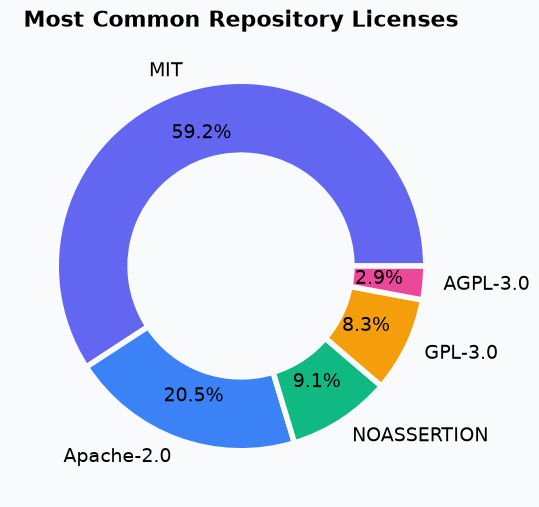

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6), facecolor="#f8fafc")
ax.set_facecolor("#f8fafc")
plt.pie(
    top_used_license["count"],
    labels=top_used_license["license"],
    startangle=0,
    shadow=False,
    pctdistance=0.75,
    autopct="%0.1f%%",
    wedgeprops={"width": 0.4, "edgecolor": "#f8fafc", "linewidth": 4},
    colors=["#6366f1", "#3b82f6", "#10b981", "#f59e0b", "#ec4899"],
    textprops={"color": "black", "fontsize": 14, "fontweight": "medium"},
)
plt.title("Most Common Repository Licenses",fontsize=16, fontweight="bold", color="black")
plt.show()



What does this show?

This chart shows the distribution of the most commonly used specified licenses among the repositories.


In [315]:
print(
    f"Key Insight: {top_used_license['license'].iloc[0]} is the most commonly "
    f"specified license, used by {int(top_used_license['count'].iloc[0]):,} repositories."
)


Key Insight: MIT is the most commonly specified license, used by 10,113 repositories.


<h2 style="color: #f4ed60; font-family: 'Courier New', monospace;">Development Practices Analysis</h2>

In [ ]:
true_counts = df[["has_issues", "has_wiki", "has_discussions"]].sum().reset_index()
true_counts.columns=["feature","count"]
true_counts


,feature,count
0,has_issues,23838
1,has_wiki,18784
2,has_discussions,4249


In [ ]:
fig = px.bar(
    true_counts,
    x="feature",
    y="count",
    title="Repository Feature Adoption",
    color="feature",
    color_discrete_sequence=[
        "#6366f1",
        "#3b82f6",
        "#10b981",
        "#f59e0b",
        "#ec4899",
    ]
)
fig.update_layout(
    plot_bgcolor="#f8fafc",
    paper_bgcolor="#f8fafc",
    font={"family": "Inter, sans-serif", "size": 13, "color": "#051837"},
    xaxis={"title": "Repository Feature"},
    yaxis={"title": "Number of Repositories"},
    title={"x":0.5}
)
fig.show()

What does this show?

"This chart compares the number of repositories where Issues, Wiki, and Discussions are enabled."

In [316]:
print(
    f"Key Insight: {true_counts.loc[true_counts['count'].idxmax(), 'feature']} "
    f"is the most commonly enabled repository feature, present in "
    f"{int(true_counts['count'].max()):,} repositories."
)


Key Insight: has_issues is the most commonly enabled repository feature, present in 23,838 repositories.


<h2 style="color: #f4ed60; font-family: 'Courier New', monospace;">Repository Activity Analysis</h2>


In [ ]:
df["created_at"] = pd.to_datetime(df["created_at"])
df["updated_at"] = pd.to_datetime(df["updated_at"])


In [ ]:
df["updated_year"] = df["updated_at"].dt.year


In [ ]:
year_count=df.groupby("updated_year")['url'].count()

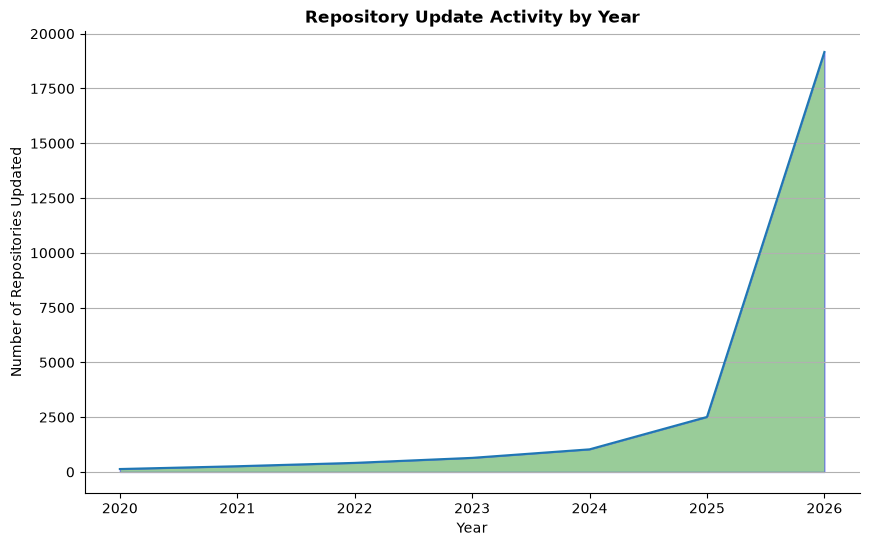

In [322]:
fig=plt.figure(figsize=(10,6))
ax=plt.axes()
plt.plot(year_count.index,year_count.values)
plt.title("Repository Update Activity by Year",fontweight="bold")
plt.fill_between(year_count.index, year_count.values,0,alpha=0.4,color="green",edgecolor="blue")
plt.xlabel("Year")
plt.ylabel("Number of Repositories Updated")
plt.grid(axis="y")
ax.spines[["top","right"]].set_visible(False)
plt.show()


What does this show?

This chart shows the number of repositories whose latest recorded update falls within each year.



In [317]:
highest_update_year = year_count.idxmax()

print(
    f"Key Insight: Repository update activity was highest in "
    f"{int(highest_update_year)}, with {int(year_count.max()):,} repositories."
)


Key Insight: Repository update activity was highest in 2026, with 19,168 repositories.


<h1 style="color: #2ecc71;">Final Key Findings</h1>



In [319]:
print("\n" + "=" * 65)
print("FINAL KEY FINDINGS")
print("=" * 65)

print(
    f"\n1. Repository Growth: Repository creation was highest in "
    f"{int(repo_count.loc[repo_count['url'].idxmax(), 'created_year'])}, "
    f"with {int(repo_count['url'].max()):,} repositories."
)

print(
    f"\n2. Repository Popularity: {top_repos['name'].iloc[0]} was the "
    f"most-starred repository, with {int(top_repos['stars'].iloc[0]):,} stars."
)

correlation_pairs = correlation_data.unstack()
correlation_pairs = correlation_pairs[
    correlation_pairs.index.get_level_values(0)
    != correlation_pairs.index.get_level_values(1)
]
strongest_pair = correlation_pairs.abs().idxmax()

print(
    f"\n3. Community Engagement: The strongest relationship was between "
    f"{strongest_pair[0]} and {strongest_pair[1]}, with a correlation of "
    f"{correlation_pairs[strongest_pair]:.2f}."
)

print(
    f"\n4. Issue Activity: {top_repos_by_issues['name'].iloc[-1]} had the "
    f"highest number of open issues, with "
    f"{int(top_repos_by_issues['open_issues'].iloc[-1]):,} issues."
)

print(
    f"\n5. Licensing: {top_used_license['license'].iloc[0]} was the most "
    f"commonly specified license, used by "
    f"{int(top_used_license['count'].iloc[0]):,} repositories."
)

print(
    f"\n6. Development Practices: {true_counts.loc[true_counts['count'].idxmax(), 'feature']} "
    f"was the most commonly enabled repository feature, present in "
    f"{int(true_counts['count'].max()):,} repositories."
)

print(
    f"\n7. Repository Activity: Update activity was highest in "
    f"{int(year_count.idxmax())}, with {int(year_count.max()):,} repositories."
)



FINAL KEY FINDINGS

1. Repository Growth: Repository creation was highest in 2026, with 3,631 repositories.

2. Repository Popularity: NousResearch/hermes-agent was the most-starred repository, with 250,707 stars.

3. Community Engagement: The strongest relationship was between stars and forks, with a correlation of 0.87.

4. Issue Activity: NousResearch/hermes-agent had the highest number of open issues, with 48,305 issues.

5. Licensing: MIT was the most commonly specified license, used by 10,113 repositories.

6. Development Practices: has_issues was the most commonly enabled repository feature, present in 23,838 repositories.

7. Repository Activity: Update activity was highest in 2026, with 19,168 repositories.
